In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
data = pd.read_csv(r'C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\african_sponsorship_brands.csv', delimiter=';')
print("First 5 rows of the dataset:")
display(data.head())

First 5 rows of the dataset:


,brand_id,brand_name,sponsorship_deals,product_types,location,annual_revenue,contact_email,phone_number,website,created_at
0,150,Kappa,Football Club,Sportswear,Uganda,$47.4B,contact@kappa.com,2 557 629 850,https://www.kappa.com,03/03/2025
1,467,Le Coq Sportif,Basketball Team,Basketball,Zambia,$47.3B,contact@le coq sportif.com,2 553 629 252,https://www.le coq sportif.com,03/03/2025
2,464,Puma,Basketball Team,Footwear,Egypt,$29.7B,contact@puma.com,1 766 661 003,https://www.puma.com,03/03/2025
3,421,AY Sport,Football Club,Sportswear,Ghana,$39.0B,contact@ay sport.com,2 368 519 018,https://www.ay sport.com,03/03/2025
4,47,Kappa,National Team,National Team,Egypt,$47.2B,contact@kappa.com,1 635 733 744,https://www.kappa.com,03/03/2025


In [20]:
print("\nDataset Info:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())
print("\nSummary Statistics (Numerical):")
print(data.describe())
print("\nSummary Statistics (Categorical):")
print(data.describe(include=['object']))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand_id           600 non-null    int64 
 1   brand_name         600 non-null    object
 2   sponsorship_deals  600 non-null    object
 3   product_types      600 non-null    object
 4   location           600 non-null    object
 5   annual_revenue     600 non-null    object
 6   contact_email      600 non-null    object
 7   phone_number       600 non-null    object
 8   website            600 non-null    object
 9   created_at         600 non-null    object
dtypes: int64(1), object(9)
memory usage: 47.0+ KB

Missing Values:
brand_id             0
brand_name           0
sponsorship_deals    0
product_types        0
location             0
annual_revenue       0
contact_email        0
phone_number         0
website              0
created_at           0
dtype: int64

Summ

In [21]:
data['annual_revenue'] = data['annual_revenue'].str.replace('$', '').str.replace('B', '').astype(float) * 1e9
# Fix phone_number spacing and standardize
data['phone_number'] = data['phone_number'].str.replace(' ', '')
# Correct website and email spacing
data['contact_email'] = data['contact_email'].str.replace(' ', '')
data['website'] = data['website'].str.replace(' ', '')
# Convert created_at to datetime (assuming MM/DD/YYYY format)
data['created_at'] = pd.to_datetime(data['created_at'], format='%m/%d/%Y', errors='coerce')
print("\nCleaned Data (First 5 rows):")
display(data.head())


Cleaned Data (First 5 rows):


,brand_id,brand_name,sponsorship_deals,product_types,location,annual_revenue,contact_email,phone_number,website,created_at
0,150,Kappa,Football Club,Sportswear,Uganda,4.740000e+10,contact@kappa.com,2557629850,https://www.kappa.com,2025-03-03
1,467,Le Coq Sportif,Basketball Team,Basketball,Zambia,4.730000e+10,contact@lecoqsportif.com,2553629252,https://www.lecoqsportif.com,2025-03-03
2,464,Puma,Basketball Team,Footwear,Egypt,2.970000e+10,contact@puma.com,1766661003,https://www.puma.com,2025-03-03
3,421,AY Sport,Football Club,Sportswear,Ghana,3.900000e+10,contact@aysport.com,2368519018,https://www.aysport.com,2025-03-03
4,47,Kappa,National Team,National Team,Egypt,4.720000e+10,contact@kappa.com,1635733744,https://www.kappa.com,2025-03-03


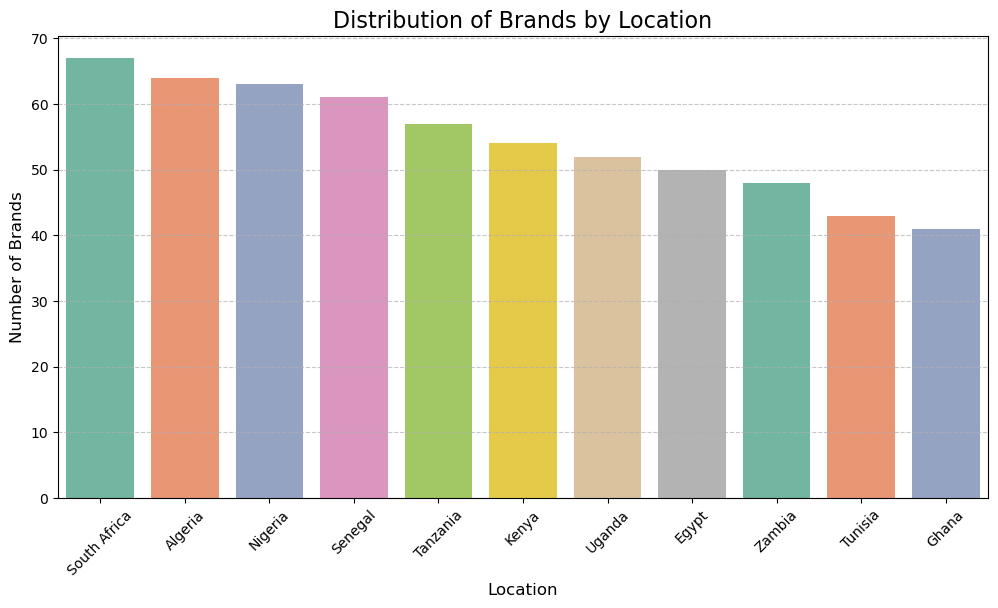

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='location', palette='Set2', order=data['location'].value_counts().index)
plt.title('Distribution of Brands by Location', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Brands', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

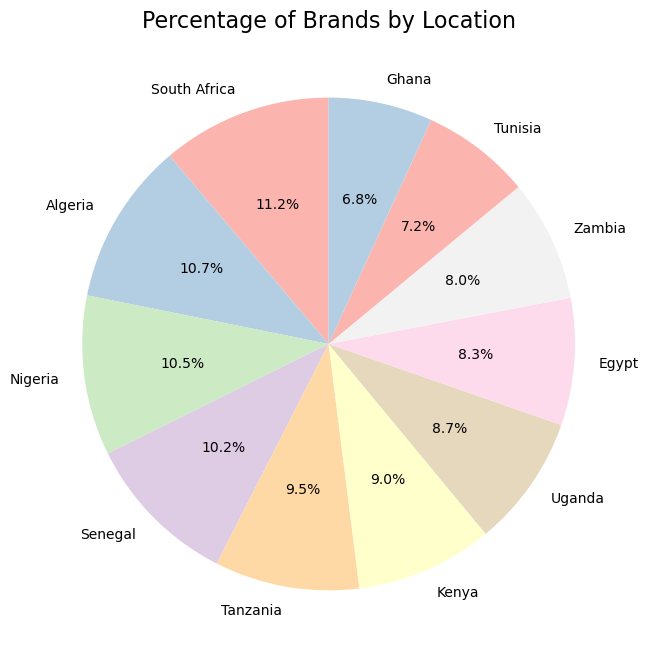

In [23]:
plt.figure(figsize=(8, 8))
data['location'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Pastel1'), startangle=90)
plt.title('Percentage of Brands by Location', fontsize=16)
plt.ylabel('')
plt.show()

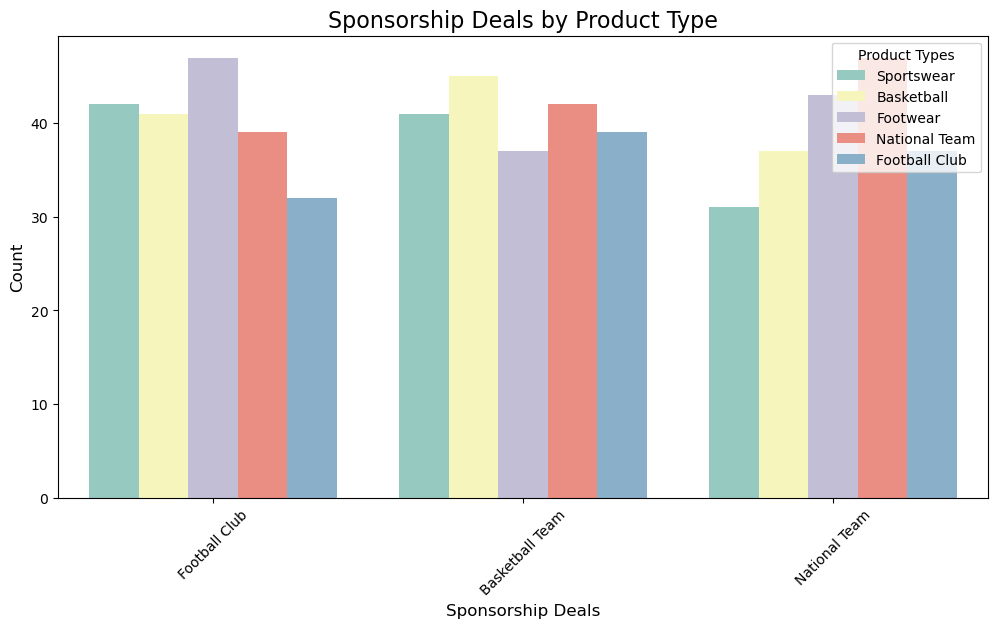

In [24]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='sponsorship_deals', hue='product_types', palette='Set3')
plt.title('Sponsorship Deals by Product Type', fontsize=16)
plt.xlabel('Sponsorship Deals', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Product Types')
plt.show()

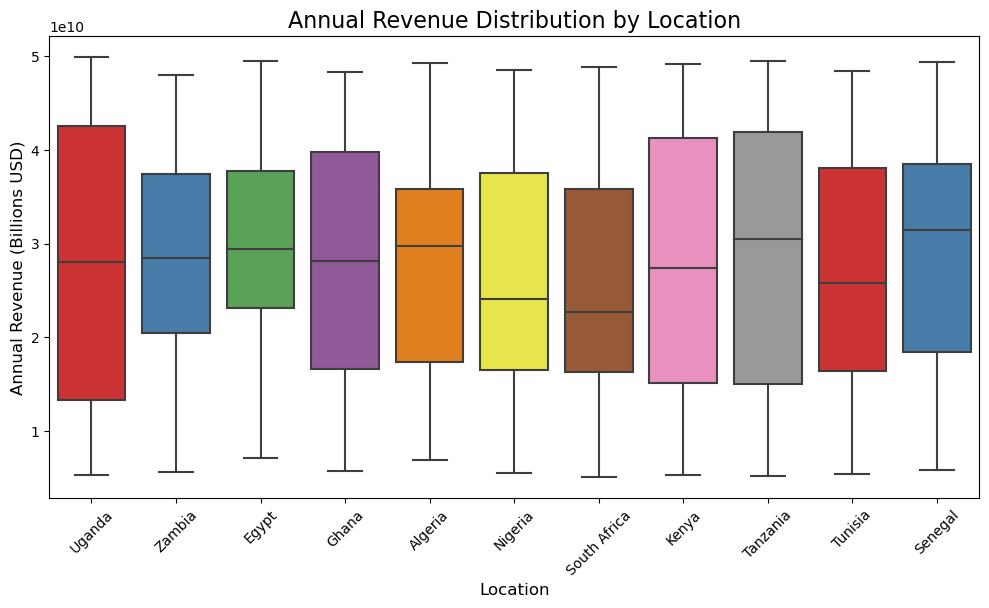

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='annual_revenue', data=data, palette='Set1')
plt.title('Annual Revenue Distribution by Location', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Annual Revenue (Billions USD)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

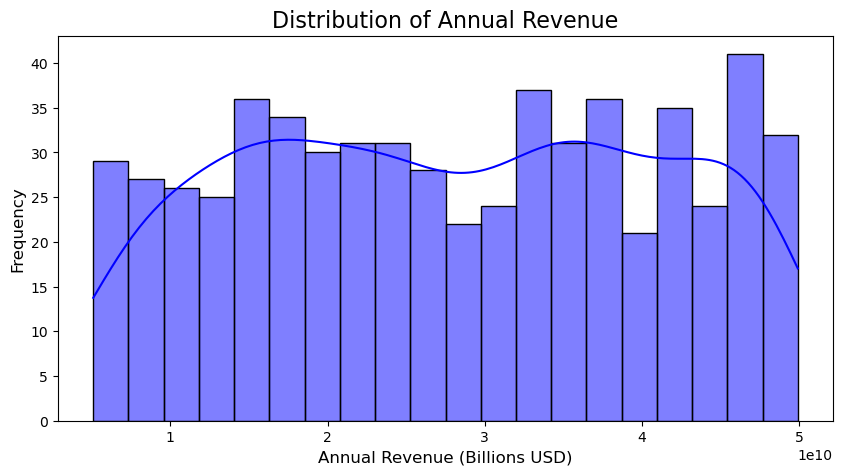

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(data['annual_revenue'], bins=20, kde=True, color='blue')
plt.title('Distribution of Annual Revenue', fontsize=16)
plt.xlabel('Annual Revenue (Billions USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

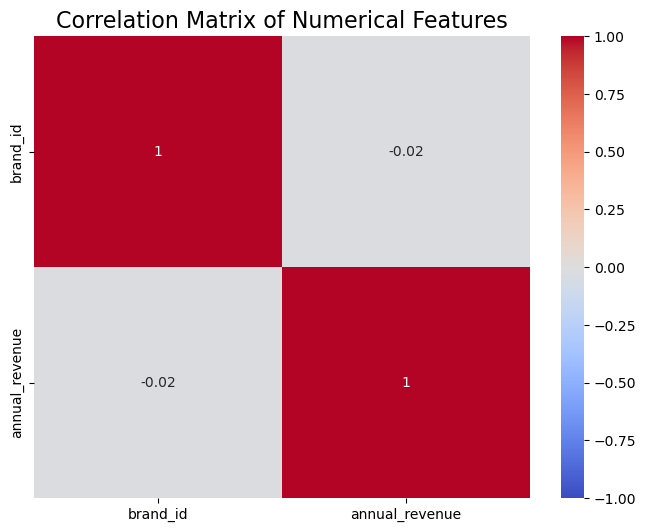

In [27]:
numerical_cols = ['brand_id', 'annual_revenue']
corr_matrix = data[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

In [28]:
le = LabelEncoder()
data_encoded = data.copy()
for col in ['brand_name', 'sponsorship_deals', 'product_types', 'location']:
    data_encoded[col] = le.fit_transform(data_encoded[col])

# Standardize numerical features
scaler = StandardScaler()
numerical_features = ['annual_revenue']
data_encoded[numerical_features] = scaler.fit_transform(data_encoded[numerical_features])





Columns in data after PCA and clustering: ['brand_id', 'brand_name', 'sponsorship_deals', 'product_types', 'location', 'annual_revenue', 'contact_email', 'phone_number', 'website', 'created_at', 'cluster', 'PCA1', 'PCA2']
First few rows with PCA and cluster:


,PCA1,PCA2,cluster
0,4.069126,-2.061121,1
1,5.104058,1.932074,1
2,-3.914083,0.047452,2
3,-2.929109,-1.977381,2
4,-3.911798,-0.980197,2


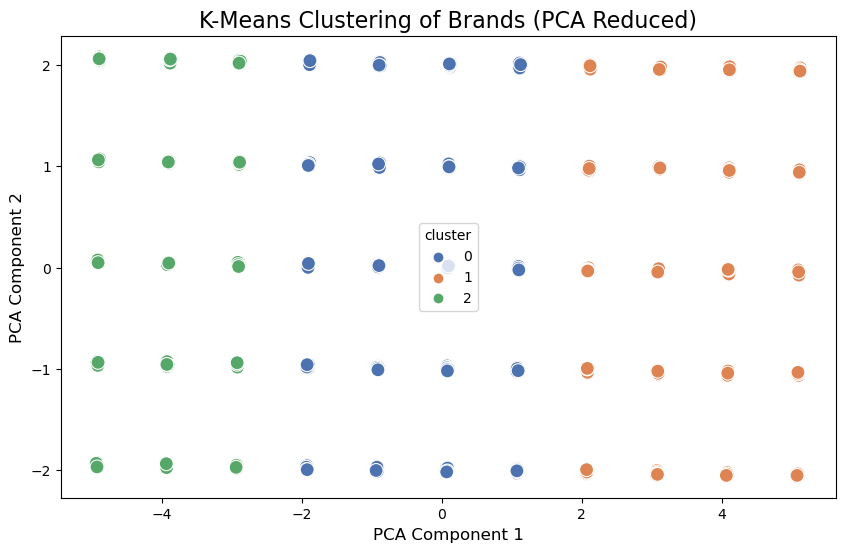

In [31]:
# Cell 9: K-Means Clustering
X = data_encoded[['annual_revenue', 'sponsorship_deals', 'product_types', 'location']]
kmeans = KMeans(n_clusters=3, random_state=42)
data['cluster'] = kmeans.fit_predict(X)  # Assign clusters directly to data

# PCA for Visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
data['PCA1'] = pca_result[:, 0]  # Add PCA columns directly to data
data['PCA2'] = pca_result[:, 1]

# Verify columns exist
print("Columns in data after PCA and clustering:", data.columns.tolist())
print("First few rows with PCA and cluster:")
display(data[['PCA1', 'PCA2', 'cluster']].head())

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=data, palette='deep', s=100)
plt.title('K-Means Clustering of Brands (PCA Reduced)', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.show()

In [32]:
# Cell 10: Cluster Analysis
print("\nCluster Summary:")
cluster_summary = data.groupby('cluster').agg({
    'brand_name': 'count',
    'annual_revenue': 'mean',
    'location': lambda x: x.mode()[0],
    'sponsorship_deals': lambda x: x.mode()[0]
}).rename(columns={'brand_name': 'count'})
print(cluster_summary)

# Save Enhanced Data
data.to_csv(r'C:\Users\Hidou\Documents\4DS1\SEM2\PI\DATA COLLECTED FOR PI\BRANDS\Final\enhanced_african_sponsorship_brands.csv', index=False)
print("Enhanced data saved.")


Cluster Summary:
         count  annual_revenue      location sponsorship_deals
cluster                                                       
0          245    2.741102e+10  South Africa     National Team
1          200    2.837950e+10      Tanzania     Football Club
2          155    2.835032e+10       Algeria   Basketball Team
Enhanced data saved.
